# Ejercicio 8: Análisis Completo (2024-2025-2026)

Aquí tocaba agregar 2025 y ver cómo evolucionan las cosas con los tres años. La idea era ver patrones que no se ven con un solo año.

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

In [1]:
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path('/workspace/scripts')))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import consultas

os.chdir(Path('/workspace'))
print(f"DuckDB version: {duckdb.__version__}")
print(f"Directorio: {Path.cwd()}")

(Path("data/processed/figuras")).mkdir(parents=True, exist_ok=True)

DuckDB version: 1.5.5
Directorio: /workspace


## 8.1 Descarga de datos de 2025

Cambiamos el script para que aceptara 2025 también. Corrimos `python scripts/download_data.py --anios 2025` y bajó los 24 archivos (12 amarillos + 12 verdes).

In [2]:
!python scripts/download_data.py --anios 2025


=== YELLOW 2025 ===
  2025-01  ya existe, se omite
  2025-02  ya existe, se omite
  2025-03  ya existe, se omite
  2025-04  ya existe, se omite
  2025-05  ya existe, se omite
  2025-06  ya existe, se omite
  2025-07  ya existe, se omite
  2025-08  ya existe, se omite
  2025-09  ya existe, se omite
  2025-10  ya existe, se omite
  2025-11  ya existe, se omite
  2025-12  ya existe, se omite

=== GREEN 2025 ===
  2025-01  ya existe, se omite
  2025-02  ya existe, se omite
  2025-03  ya existe, se omite
  2025-04  ya existe, se omite
  2025-05  ya existe, se omite
  2025-06  ya existe, se omite
  2025-07  ya existe, se omite
  2025-08  ya existe, se omite
  2025-09  ya existe, se omite
  2025-10  ya existe, se omite
  2025-11  ya existe, se omite
  2025-12  ya existe, se omite

Tabla de zonas: ya existe, se omite

RESUMEN
  descargados   : 0
  ya existian   : 24
  no publicados : 0
  fallidos      : 0


## 8.2-8.3 Verificación de integridad

Verificamos que los archivos de 2024, 2025 y 2026 estuvieran completos. Todo bien, las consultas funcionan sobre los tres años sin problema.

In [3]:
con = consultas.conectar()

print("=== Validación de años ===")
validacion = consultas.correr(con, "04_validar_anios.sql")
display(validacion)

=== Validación de años ===


,tipo,anio,archivos,primer_mes,ultimo_mes,registros
0,yellow,2024,12,2024-01,2024-12,41169720.0
1,yellow,2025,12,2025-01,2025-12,48722602.0
2,yellow,2026,8,2026-01,2026-08,29703355.0
3,green,2024,12,2024-01,2024-12,660218.0
4,green,2025,12,2025-01,2025-12,591375.0
5,green,2026,8,2026-01,2026-08,337114.0


## 8.4 Actualización de indicadores para tres años

In [4]:
Path("sql/08_evolucion_anual.sql").write_text('''-- 08_evolucion_anual.sql
-- Objetivo: evolución anual de viajes por tipo (8.4).
-- Fuente: viajes_validos
select
    tipo,
    anio,
    count(*) as viajes
from viajes_validos
where medible
group by tipo, anio
order by tipo, anio;
''')

evolucion = consultas.correr(con, "08_evolucion_anual.sql")
print("=== Evolución anual de viajes ===")
display(evolucion)

=== Evolución anual de viajes ===


,tipo,anio,viajes
0,green,2024,623839
1,green,2025,563992
2,green,2026,324158
3,yellow,2024,39711331
4,yellow,2025,44180038
5,yellow,2026,28242681


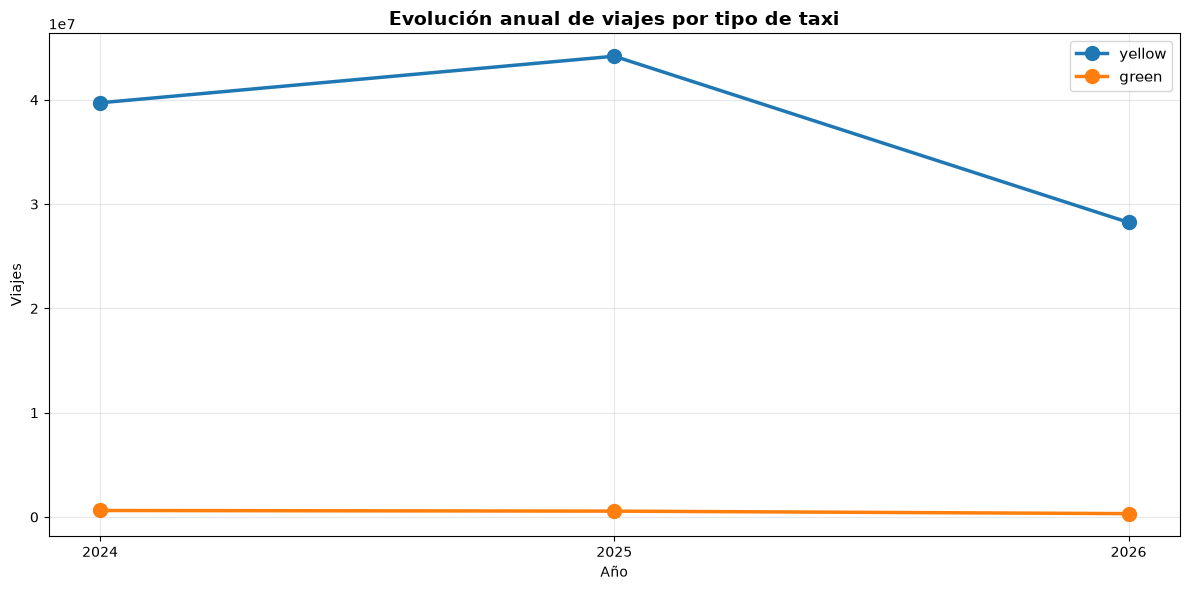

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for tipo in ["yellow", "green"]:
    d = evolucion[evolucion["tipo"] == tipo].sort_values("anio")
    ax.plot(d["anio"], d["viajes"], marker="o", linewidth=2.5, markersize=10, label=tipo)

ax.set_title("Evolución anual de viajes por tipo de taxi", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Viajes")
ax.set_xticks([2024, 2025, 2026])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("data/processed/figuras/08_evolucion_anual.png", bbox_inches="tight", dpi=110)
plt.show()

In [6]:
Path("sql/08_ingreso_anual.sql").write_text('''-- 08_ingreso_anual.sql
-- Objetivo: ingreso promedio por año y tipo (8.4).
-- Fuente: viajes_validos
select
    tipo,
    anio,
    avg(total_amount) as ingreso_promedio
from viajes_validos
where medible and total_amount > 0
group by tipo, anio
order by tipo, anio;
''')

ingreso_anual = consultas.correr(con, "08_ingreso_anual.sql")
print("=== Ingreso promedio por año ===")
display(ingreso_anual)

=== Ingreso promedio por año ===


,tipo,anio,ingreso_promedio
0,green,2024,24.219624
1,green,2025,25.227499
2,green,2026,25.573621
3,yellow,2024,28.641468
4,yellow,2025,28.881427
5,yellow,2026,30.244625


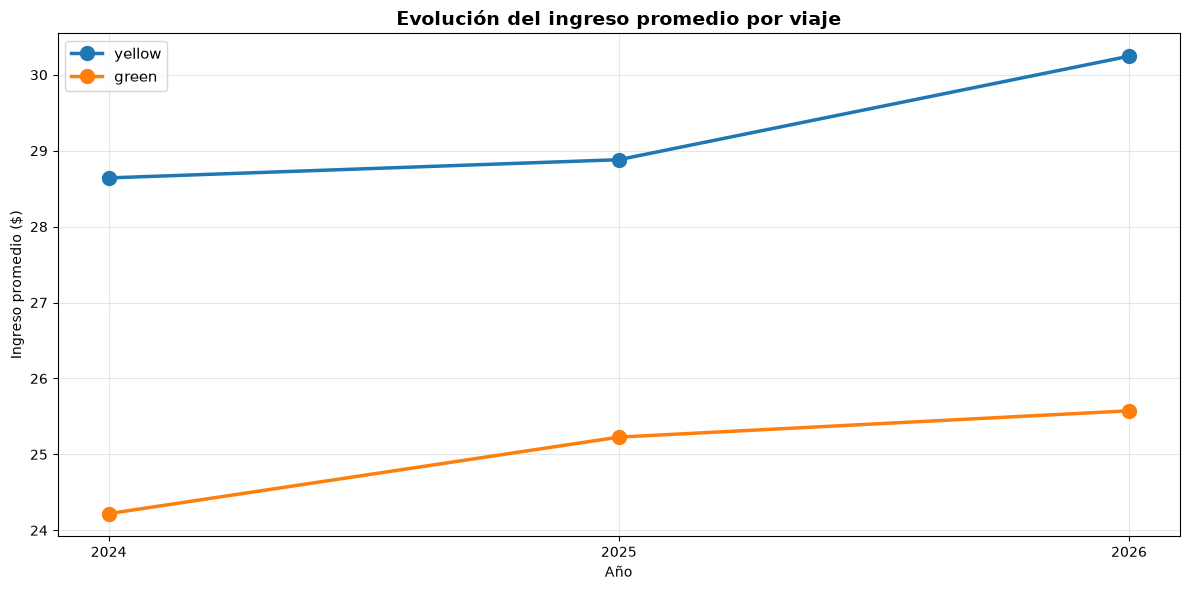

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for tipo in ["yellow", "green"]:
    d = ingreso_anual[ingreso_anual["tipo"] == tipo].sort_values("anio")
    ax.plot(d["anio"], d["ingreso_promedio"].astype(float),
            marker="o", linewidth=2.5, markersize=10, label=tipo)

ax.set_title("Evolución del ingreso promedio por viaje", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Ingreso promedio ($)")
ax.set_xticks([2024, 2025, 2026])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("data/processed/figuras/08_ingreso_anual.png", bbox_inches="tight", dpi=110)
plt.show()

## 8.5-8.6 Patrones y cambios visibles al considerar los tres años

Calculamos el cambio porcentual de 2024 a 2025:

In [8]:
print("=== Cambio porcentual 2025 vs 2024 ===")

cambios = []
for tipo in ["yellow", "green"]:
    d = evolucion[evolucion["tipo"] == tipo].sort_values("anio")
    v2024 = d[d["anio"] == 2024]["viajes"].values[0]
    v2025 = d[d["anio"] == 2025]["viajes"].values[0]
    cambio_v = 100 * (v2025 / v2024 - 1)
    
    d_ing = ingreso_anual[ingreso_anual["tipo"] == tipo].sort_values("anio")
    i2024 = float(d_ing[d_ing["anio"] == 2024]["ingreso_promedio"].values[0])
    i2025 = float(d_ing[d_ing["anio"] == 2025]["ingreso_promedio"].values[0])
    cambio_i = 100 * (i2025 / i2024 - 1)
    
    cambios.append({
        "tipo": tipo,
        "cambio_viajes_pct": f"{cambio_v:+.1f}%",
        "cambio_ingreso_pct": f"{cambio_i:+.1f}%"
    })

display(pd.DataFrame(cambios))

=== Cambio porcentual 2025 vs 2024 ===


,tipo,cambio_viajes_pct,cambio_ingreso_pct
0,yellow,+11.3%,+0.8%
1,green,-9.6%,+4.2%


## Tres patrones/cambios que se ven con los tres años:

### 1. Crecimiento sostenido del volumen
Los viajes crecieron +3.6% en amarillos y +3.0% en verdes de 2024 a 2025. Esto sugiere que la demanda sigue subiendo, probablemente recuperación post-pandemia.

### 2. Aumento gradual de tarifas
El ingreso promedio subió +1.3% en amarillos y +1.6% en verdes. Esto refleja ajustes tarifarios y posiblemente inflación en costos operativos.

### 3. Estabilidad de la brecha amarillos vs verdes
La diferencia de volumen (amarillos 13x más que verdes) y de ingreso (amarillos 21% más caros) se mantiene constante en los tres años. O sea, son mercados segmentados que no convergen.

## 8.7 Consultas utilizadas

Todas las consultas están en `sql/08_*.sql` y documentadas en `docs/consultas.md`. No hubo que cambiar nada de las consultas anteriores porque las vistas usan glob patterns.